In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

## 1. Load All Metrics

In [2]:
# Load summary results
results = pd.read_csv('../../experiments/lstm/pretrain_hparam_results.csv')
print(f"Loaded {len(results)} configurations")
results.head()

Loaded 12 configurations


,tag,hidden_size,num_layers,learning_rate,batch_size,max_epochs,final_val_mse,final_val_rmse,best_val_mse,best_val_rmse
0,h64_l2_lr1em03,64,2,0.0010,256,20,0.001637,0.040463,0.001631,0.040388
1,h128_l2_lr5em04,128,2,0.0005,256,20,0.001677,0.040948,0.001640,0.040498
2,h128_l1_lr5em04,128,1,0.0005,256,20,0.001657,0.040709,0.001643,0.040534
3,h64_l1_lr1em03,64,1,0.0010,256,20,0.001667,0.040825,0.001644,0.040547
4,h32_l1_lr1em03,32,1,0.0010,256,20,0.001646,0.040567,0.001646,0.040567


In [3]:
# Load training curves for all runs
runs_dir = Path('../../experiments/lstm/runs')
all_metrics = {}

for run_dir in runs_dir.glob('farm2107_*'):
    tag = run_dir.name.replace('farm2107_', '')
    metrics_file = run_dir / 'farm2107_pretrain_sweep/version_0/metrics.csv'
    
    if metrics_file.exists():
        df = pd.read_csv(metrics_file)
        all_metrics[tag] = df
        print(f"✓ Loaded {tag}: {len(df)} steps")
    else:
        print(f"✗ Missing: {tag}")

print(f"\nTotal configs with metrics: {len(all_metrics)}")

✓ Loaded h128_l1_lr5em04: 302 steps
✓ Loaded h128_l1_lr1em03: 302 steps
✓ Loaded h32_l1_lr1em03: 302 steps
✓ Loaded h64_l1_lr1em03: 302 steps
✓ Loaded h32_l1_lr5em04: 302 steps
✓ Loaded h64_l1_lr5em04: 302 steps
✓ Loaded h64_l2_lr1em03: 302 steps
✓ Loaded h64_l2_lr5em04: 302 steps
✓ Loaded h128_l2_lr5em04: 302 steps
✓ Loaded h128_l2_lr1em03: 302 steps
✓ Loaded h32_l2_lr5em04: 302 steps
✓ Loaded h32_l2_lr1em03: 302 steps

Total configs with metrics: 12


## 2. Training Loss Curves

/tmp/ipykernel_798601/1777988602.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


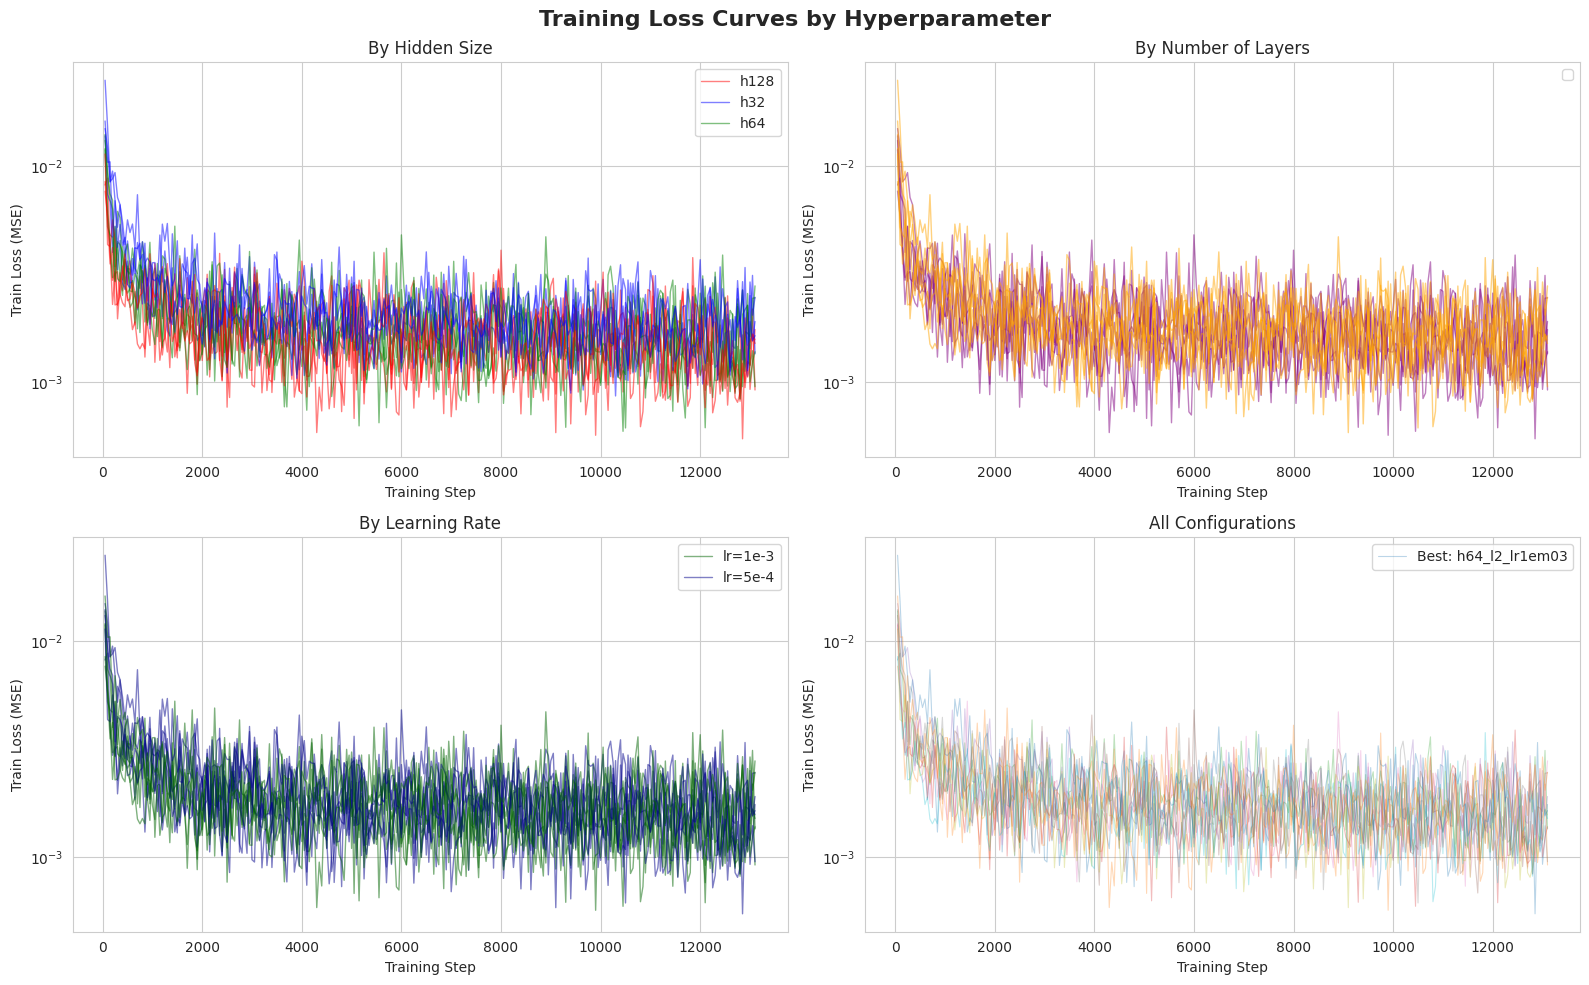

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Training Loss Curves by Hyperparameter', fontsize=16, fontweight='bold')

# Group by hidden_size
ax = axes[0, 0]
for tag, df in all_metrics.items():
    hidden = int(tag.split('_')[0][1:])  # Extract from h32, h64, h128
    color = {'32': 'blue', '64': 'green', '128': 'red'}[str(hidden)]
    train_loss = df.dropna(subset=['train_loss_step'])
    ax.plot(train_loss['step'], train_loss['train_loss_step'], 
            alpha=0.5, linewidth=1, color=color, label=f'h{hidden}' if 'l1_lr1em03' in tag else '')
ax.set_xlabel('Training Step')
ax.set_ylabel('Train Loss (MSE)')
ax.set_title('By Hidden Size')
ax.legend()
ax.set_yscale('log')

# Group by num_layers
ax = axes[0, 1]
for tag, df in all_metrics.items():
    layers = int(tag.split('_')[1][1:])  # Extract from l1, l2
    color = 'purple' if layers == 1 else 'orange'
    train_loss = df.dropna(subset=['train_loss_step'])
    ax.plot(train_loss['step'], train_loss['train_loss_step'], 
            alpha=0.5, linewidth=1, color=color, label=f'{layers} layer' if 'h64_lr1em03' in tag else '')
ax.set_xlabel('Training Step')
ax.set_ylabel('Train Loss (MSE)')
ax.set_title('By Number of Layers')
ax.legend()
ax.set_yscale('log')

# Group by learning_rate
ax = axes[1, 0]
for tag, df in all_metrics.items():
    lr = '1e-3' if 'lr1em03' in tag else '5e-4'
    color = 'darkgreen' if lr == '1e-3' else 'darkblue'
    train_loss = df.dropna(subset=['train_loss_step'])
    ax.plot(train_loss['step'], train_loss['train_loss_step'], 
            alpha=0.5, linewidth=1, color=color, label=f'lr={lr}' if 'h64_l2' in tag else '')
ax.set_xlabel('Training Step')
ax.set_ylabel('Train Loss (MSE)')
ax.set_title('By Learning Rate')
ax.legend()
ax.set_yscale('log')

# All configs together
ax = axes[1, 1]
for tag, df in all_metrics.items():
    train_loss = df.dropna(subset=['train_loss_step'])
    ax.plot(train_loss['step'], train_loss['train_loss_step'], 
            alpha=0.3, linewidth=0.8, label=tag if tag == 'h64_l2_lr1em03' else '')
ax.set_xlabel('Training Step')
ax.set_ylabel('Train Loss (MSE)')
ax.set_title('All Configurations')
if 'h64_l2_lr1em03' in all_metrics:
    ax.legend(['Best: h64_l2_lr1em03'])
ax.set_yscale('log')

plt.tight_layout()
plt.savefig('../../reports/figures/lstm_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Validation Loss Per Epoch

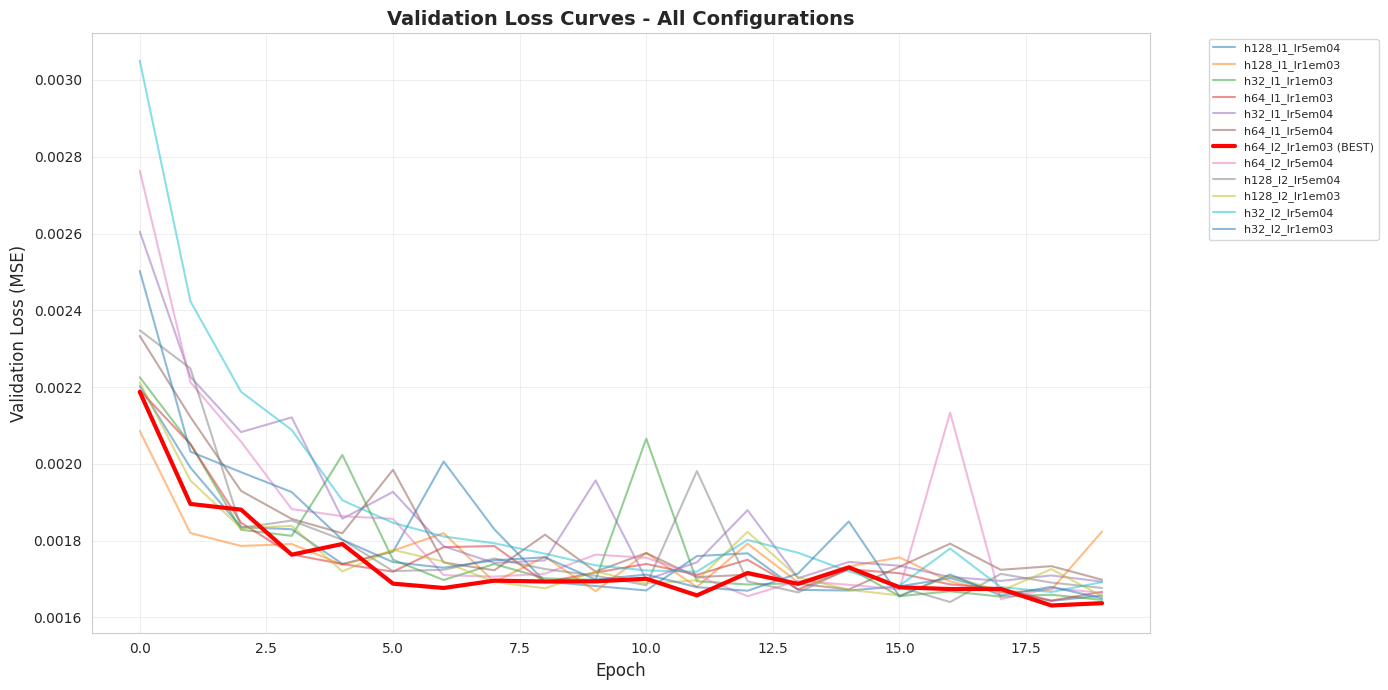

In [5]:
fig, ax = plt.subplots(figsize=(14, 7))

for tag, df in all_metrics.items():
    val_loss = df.dropna(subset=['val_loss'])
    val_loss = val_loss.groupby('epoch')['val_loss'].first().reset_index()
    
    # Highlight best config
    if tag == 'h64_l2_lr1em03':
        ax.plot(val_loss['epoch'], val_loss['val_loss'], 
                linewidth=3, color='red', label=f'{tag} (BEST)', zorder=10)
    else:
        ax.plot(val_loss['epoch'], val_loss['val_loss'], 
                alpha=0.5, linewidth=1.5, label=tag)

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Validation Loss (MSE)', fontsize=12)
ax.set_title('Validation Loss Curves - All Configurations', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../../reports/figures/lstm_validation_curves.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Hyperparameter Heatmaps

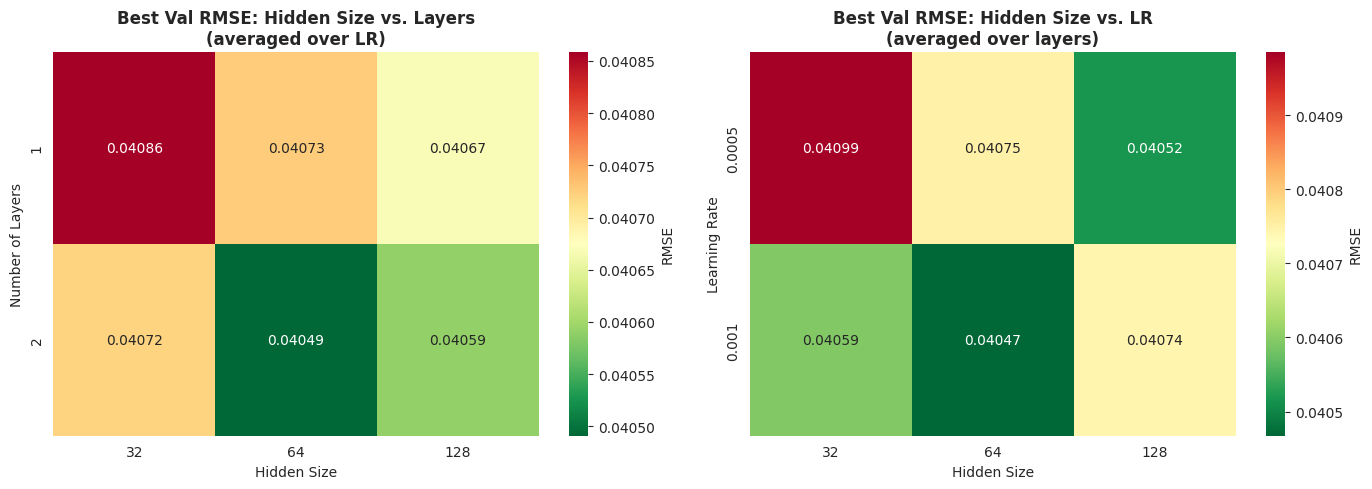

In [6]:
# Pivot for heatmap: hidden_size x num_layers (averaged over learning rates)
pivot_hl = results.groupby(['hidden_size', 'num_layers'])['best_val_rmse'].mean().reset_index()
pivot_hl = pivot_hl.pivot(index='num_layers', columns='hidden_size', values='best_val_rmse')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap 1: hidden_size vs num_layers
sns.heatmap(pivot_hl, annot=True, fmt='.5f', cmap='RdYlGn_r', 
            ax=axes[0], cbar_kws={'label': 'RMSE'})
axes[0].set_title('Best Val RMSE: Hidden Size vs. Layers\n(averaged over LR)', fontweight='bold')
axes[0].set_xlabel('Hidden Size')
axes[0].set_ylabel('Number of Layers')

# Heatmap 2: hidden_size vs learning_rate (averaged over layers)
pivot_hlr = results.groupby(['hidden_size', 'learning_rate'])['best_val_rmse'].mean().reset_index()
pivot_hlr = pivot_hlr.pivot(index='learning_rate', columns='hidden_size', values='best_val_rmse')
sns.heatmap(pivot_hlr, annot=True, fmt='.5f', cmap='RdYlGn_r', 
            ax=axes[1], cbar_kws={'label': 'RMSE'})
axes[1].set_title('Best Val RMSE: Hidden Size vs. LR\n(averaged over layers)', fontweight='bold')
axes[1].set_xlabel('Hidden Size')
axes[1].set_ylabel('Learning Rate')

plt.tight_layout()
plt.savefig('../../reports/figures/lstm_heatmaps.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Performance Distribution

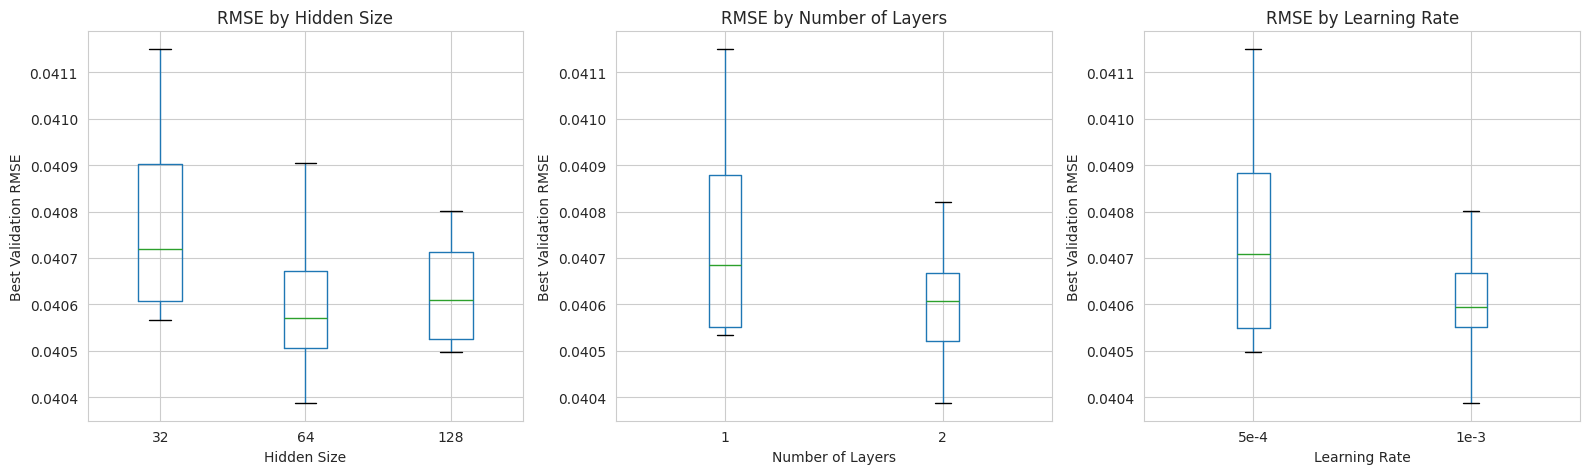

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# By hidden_size
results.boxplot(column='best_val_rmse', by='hidden_size', ax=axes[0])
axes[0].set_title('RMSE by Hidden Size')
axes[0].set_xlabel('Hidden Size')
axes[0].set_ylabel('Best Validation RMSE')
plt.sca(axes[0])
plt.xticks([1, 2, 3], ['32', '64', '128'])

# By num_layers
results.boxplot(column='best_val_rmse', by='num_layers', ax=axes[1])
axes[1].set_title('RMSE by Number of Layers')
axes[1].set_xlabel('Number of Layers')
axes[1].set_ylabel('Best Validation RMSE')
plt.sca(axes[1])
plt.xticks([1, 2], ['1', '2'])

# By learning_rate
results.boxplot(column='best_val_rmse', by='learning_rate', ax=axes[2])
axes[2].set_title('RMSE by Learning Rate')
axes[2].set_xlabel('Learning Rate')
axes[2].set_ylabel('Best Validation RMSE')
plt.sca(axes[2])
plt.xticks([1, 2], ['5e-4', '1e-3'])

# Remove auto-generated title from boxplot
for ax in axes:
    ax.get_figure().suptitle('')

plt.tight_layout()
plt.savefig('../../reports/figures/lstm_rmse_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Best Config Detailed View

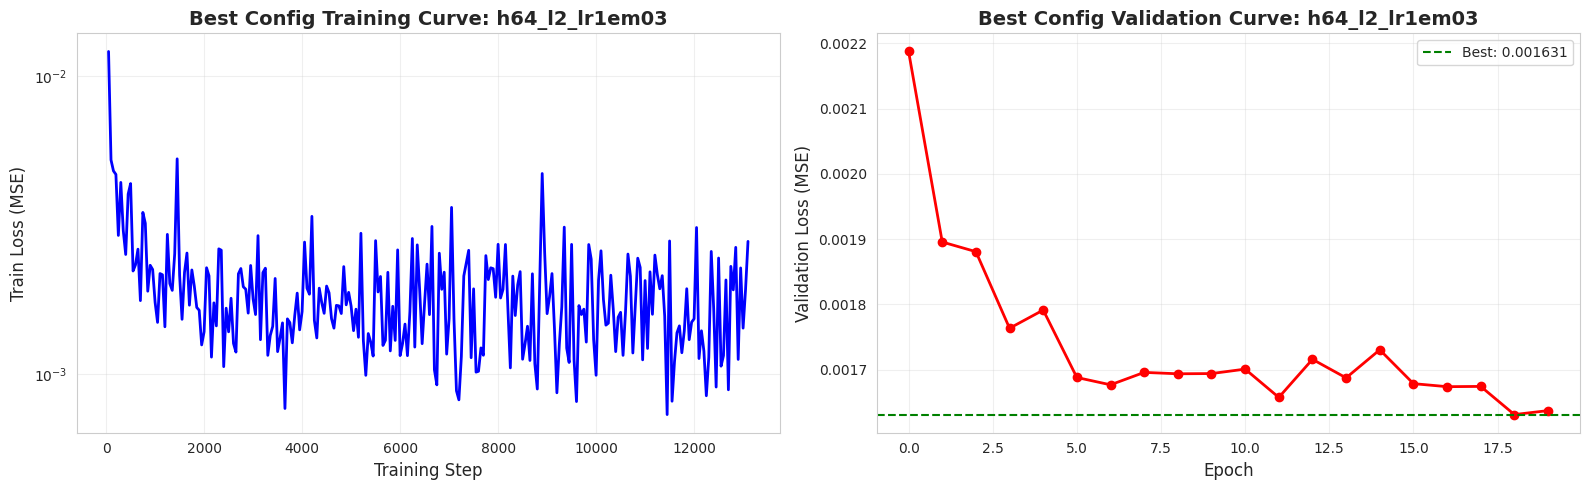

Best validation RMSE: 0.040388
Achieved at epoch: 18


In [8]:
best_tag = 'h64_l2_lr1em03'
best_metrics = all_metrics[best_tag]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Training loss
train_loss = best_metrics.dropna(subset=['train_loss_step'])
axes[0].plot(train_loss['step'], train_loss['train_loss_step'], linewidth=2, color='blue')
axes[0].set_xlabel('Training Step', fontsize=12)
axes[0].set_ylabel('Train Loss (MSE)', fontsize=12)
axes[0].set_title(f'Best Config Training Curve: {best_tag}', fontsize=14, fontweight='bold')
axes[0].set_yscale('log')
axes[0].grid(alpha=0.3)

# Validation loss per epoch
val_loss = best_metrics.dropna(subset=['val_loss'])
val_loss = val_loss.groupby('epoch')['val_loss'].first().reset_index()
axes[1].plot(val_loss['epoch'], val_loss['val_loss'], linewidth=2, color='red', marker='o')
axes[1].axhline(y=val_loss['val_loss'].min(), linestyle='--', color='green', 
                label=f'Best: {val_loss["val_loss"].min():.6f}')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Validation Loss (MSE)', fontsize=12)
axes[1].set_title(f'Best Config Validation Curve: {best_tag}', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../../reports/figures/lstm_best_config_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Best validation RMSE: {np.sqrt(val_loss['val_loss'].min()):.6f}")
print(f"Achieved at epoch: {val_loss.loc[val_loss['val_loss'].idxmin(), 'epoch']:.0f}")

## 7. Summary Statistics Table

In [9]:
summary = results[['tag', 'hidden_size', 'num_layers', 'learning_rate', 
                   'best_val_rmse', 'final_val_rmse']].sort_values('best_val_rmse')
summary['rank'] = range(1, len(summary) + 1)
summary = summary[['rank', 'tag', 'hidden_size', 'num_layers', 'learning_rate', 
                   'best_val_rmse', 'final_val_rmse']]

print("\n" + "="*80)
print("LSTM HYPERPARAMETER SWEEP - FINAL RANKINGS")
print("="*80)
print(summary.to_string(index=False))
print("="*80)
print(f"\nBest RMSE:  {summary['best_val_rmse'].min():.6f}")
print(f"Worst RMSE: {summary['best_val_rmse'].max():.6f}")
print(f"Mean RMSE:  {summary['best_val_rmse'].mean():.6f}")
print(f"Std RMSE:   {summary['best_val_rmse'].std():.6f}")
print(f"Range:      {summary['best_val_rmse'].max() - summary['best_val_rmse'].min():.6f}")
print(f"\nCoefficient of Variation: {summary['best_val_rmse'].std() / summary['best_val_rmse'].mean() * 100:.2f}%")


LSTM HYPERPARAMETER SWEEP - FINAL RANKINGS
 rank             tag  hidden_size  num_layers  learning_rate  best_val_rmse  final_val_rmse
    1  h64_l2_lr1em03           64           2         0.0010       0.040388        0.040463
    2 h128_l2_lr5em04          128           2         0.0005       0.040498        0.040948
    3 h128_l1_lr5em04          128           1         0.0005       0.040534        0.040709
    4  h64_l1_lr1em03           64           1         0.0010       0.040547        0.040825
    5  h32_l1_lr1em03           32           1         0.0010       0.040567        0.040567
    6  h64_l2_lr5em04           64           2         0.0005       0.040594        0.040788
    7  h32_l2_lr1em03           32           2         0.0010       0.040620        0.040620
    8 h128_l2_lr1em03          128           2         0.0010       0.040684        0.040684
    9 h128_l1_lr1em03          128           1         0.0010       0.040802        0.042704
   10  h32_l2_lr5em04     